# Cream Cheese Fermentation Paper

This document contains the research and development of a model to simulate the cheese fermentation process. The model is based on a system of differential equations that describe the dynamics of the fermentation process.

> This is a mock paper that demonstrates the `Formulate model` task of the Business Process of the project.

## Mathematical background

### Inputs

#### Constants

| Symbol | Value |
| ------ | ----- |
| $c_1$  | $5$   |
| $c_2$  | $12$  |

#### Variables

| Definition                                       | Symbol | Unit               | Minimum   | Maximum   | Default   |
| ------------------------------------------------ | ------ | ------------------ | --------- | --------- | --------- |
| Fermentation duration<sup>\*</sup>               | $t$    | $[h]$              | _TBD_     | _TBD_     | $12$      |
| Initial bacterial concentration                  | $X_0$  | $[cells/l]$        | $10^4$    | $10^8$    | $10^6$    |
| Initial lactic acid concentration<sup>\*\*</sup> | $p_0$  | $[\mathrm{mol/l}]$ | $10^{-8}$ | $10^{-4}$ | $10^{-6}$ |
| Bacterial growth rate                            | $\mu$  | $[cells/h]$        | $0.1$     | $2$       | $1$       |
| Lactic acid production rate per bacterium        | $q$    | $\log_{10}[mol/h]$ | $-20$     | $-10$     | $-15$     |

> \* A fermentation window of roughly 12 hours is representative, but you should
> choose a duration that makes the dynamics legible for the user.

> \*\* Minimum and maximum values are typical ranges.

### Outputs

| Definition                      | Formula                                                          | Unit        |
| ------------------------------- | ---------------------------------------------------------------- | ----------- |
| Bacterial concentration         | $X(t) = \int_{t_0}^t\left(\mu\cdot{X}\cdot\sigma(pH)\right)dt'$  | $[cells/l]$ |
| Lactic acid concentration       | $p(t) = \int_{t_0}^t\left(10^q\cdot{X}\cdot\sigma(pH)\right)dt'$ | $[mol/l]$   |
| Potential of hydrogen (pH)      | $\mathrm{pH}(t)$ = $-\log_{10}p(t)$                              | $[mol/l]$   |
| Logistic inhibition term for pH | $\sigma(pH) = (1 + e^{-c_2(pH - c_1)})^{-1}$                     | $[mol/l]$   |

> $\sigma(pH)$ is a logistic inhibition term that switches the culture off as
> the medium acidifies.

## Manual integration of ODE

Given the system of equations:

$$
\begin{aligned}
\frac{dp}{dt} &= 10^q\cdot{X}\cdot\sigma(pH), \\
\frac{dX}{dt} &= \mu\cdot{X}\cdot\sigma(pH)
\end{aligned}
$$

then,

$$
\begin{aligned}
\frac{\frac{dp}{dt}}{\frac{dX}{dt}} &= \frac{10^q\cdot{X}\cdot\sigma(pH)}{\mu\cdot{X}\cdot\sigma(pH)} \\
\frac{dp}{dX} &= \frac{10^q}{\mu}\\
dp &= \frac{10^q}{\mu}{dX}\\
\int_{p_0}^{p} dp' &= \int_{X_0}^{X} \frac{10^q}{\mu} dX'\\
p(t) - p_0 &= \frac{10^q}{\mu} (X(t) - X_0) \\
\end{aligned}
$$

Therefore,

$$
p(t) = \frac{10^q}{\mu} (X(t) - X_0) + p_0
$$

Replacing around $X$:

$$
\begin{aligned}
pH(t) &= -\log_{10}p(t) \\
\equiv pH(X) &= -\log_{10}\left(\frac{10^q}{\mu} (X - X_0) + p_0\right)
\end{aligned}
$$

and

$$
\begin{aligned}
\sigma(pH) &= (1 + e^{-c_2(pH - c_1)})^{-1} \\
\sigma(X) &= \left(1 + e^{-c_2\left(-\log_{10}\left(\frac{10^q}{\mu} \left(X - X_0\right) + p_0\right)- c_1\right)}\right)^{-1} \\
\equiv \sigma(X) &= \frac{1}{1 + e^{-c_2\left(-\log_{10}\left(\frac{10^q}{\mu} \left(X - X_0\right) + p_0\right)- c_1\right)}} \\
\equiv \sigma(X) &= \frac{1}{1 + e^{\left(c_2\log_{10}\left(\frac{10^q}{\mu} \left(X - X_0\right) + p_0\right)+c_2c_1\right)}} \\
\equiv \sigma(X) &= \frac{1}{1 + e^{log_{10}\left(\left(\frac{10^q}{\mu} \left(X - X_0\right) + p_0\right)^{c_2}+c_2c_1\right)}} \\
\equiv \sigma(X) &= \frac{1}{1 + e^{log_{10}\left(\left(\frac{10^q}{\mu} \left(X - X_0\right) + p_0\right)^{c_2}\right)}\cdot e^{{c_2}{c_1}}} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  e^{
    \frac{
      \left(
        \ln
          \left(
            \frac{10^q}{\mu} \left(X - X_0\right) + p_0
          \right)^{c_2}
      \right)
    }{
      \ln(10)
    }
  }\cdot e^{{c_2}{c_1}}
} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  e^{
    \ln
      \left(
        \left(
          \frac{10^q}{\mu} \left(X - X_0\right) + p_0
        \right)^{c_2}
    \right)
     \frac{1}{\ln(10)}
  }\cdot e^{{c_2}{c_1}}
} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  e^{
    \ln
    \left(
      \left(
        \left(
          \frac{10^q}{\mu} \left(X - X_0\right) + p_0
        \right)^{c_2}
      \right)^{\frac{1}{\ln(10)}}
    \right)
  }\cdot e^{{c_2}{c_1}}
} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  {

      \left(
        \left(
          \frac{10^q}{\mu} \left(X - X_0\right) + p_0
        \right)^{c_2}
\right)^{\frac{1}{\ln(10)}}

  }\cdot e^{{c_2}{c_1}}
} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  {
        \left(
          \frac{10^q}{\mu} \left(X - X_0\right) + p_0
        \right)
^{\frac{c_2}{\ln(10)}}

  }\cdot e^{{c_2}{c_1}}
} \\
\equiv \sigma(X) &= \frac{1}{
  1 +
  e^{{c_2}{c_1}} \cdot
  {
        \left(
          \frac{10^q}{\mu} \left(X - X_0\right) + p_0
        \right)
^{\frac{c_2}{\ln(10)}}

  }
} \\

\end{aligned}
$$

finally,

$$
\begin{aligned}
\frac{dX}{dt} &= \mu\cdot{X}\cdot\sigma(X) \\
\frac{dX}{X\cdot\sigma(X)} &= \mu~{dt} \\
\int_{X_0}^{X} \frac{
  1 +
  e^{{c_2}{c_1}} \cdot
  {
        \left(
          \frac{10^q}{\mu} \left(X' - X_0\right) + p_0
        \right)
^{\frac{c_2}{\ln(10)}}

  }
}{
  X'
}dX' &= \int_{t_0}^{t}\mu~{dt'} \\
\int_{X_0}^{X} \frac{
  1 +
  e^{60} \cdot
  {
        \left(
          \frac{10^q}{\mu} \left(X' - X_0\right) + p_0
        \right)
^{5.21}

  }
}{
  X'
}dX' &= \mu{t} \\
\end{aligned}
$$


A software integrator is necessary to solve the integral on the left side of the equation, as it does not have a closed-form solution. The integrator will allow us to compute the bacterial concentration $X(t)$ over time, which can then be used to calculate the lactic acid concentration $p(t)$ and pH values.

## Integration of ODE through software
In order to understand the problem better, I will attempt to solve the system of equations using the recommended python libraries.

In [1]:
import numpy as np # this supports most of the math operations.
import pandas as pd
from plotter import plot
from scipy.integrate import solve_ivp # This is our integrator.

## System of differential equations

Let's recreate the system of differential equations given in the problem statement:

In [2]:
def _system_equations(t, state, c1, c2, mu, q):
    X, p = state
    pH = -np.log10(np.maximum(p, 1e-14))
    sigma = 1.0 / (1.0 + np.exp(-c2 * (pH - c1)))
    dX_dt = mu * X * sigma
    dp_dt = (10**q) * X * sigma
    return [dX_dt, dp_dt]

## Integrator

The system of equations can be solved using numerical integration methods. In this case, we will use the `solve_ivp` function from the `scipy.integrate` library to solve the system of equations.

In [3]:
def predict(model_input, params=None):
    if isinstance(model_input, pd.DataFrame):
        data = model_input.to_dict(orient="records")[0]
    else:
        data = model_input

    y0 = data["y0"]
    t_start = data["t_start"]
    t_end = data["t_end"]
    t_steps = data.get("t_steps", 100)

    params = params or {}
    c1 = params.get("c1", 6.5)
    c2 = params.get("c2", 2.0)
    mu = params.get("mu", 0.4)
    q = params.get("q", -2.0)
    t_eval = np.linspace(t_start, t_end, t_steps)
    sol = solve_ivp(
        fun=_system_equations,
        t_span=(t_start, t_end),
        y0=y0,
        t_eval=t_eval,
        args=(c1, c2, mu, q),
        method="RK45",
    )
    response = pd.DataFrame(sol.y.T, columns=["X", "p"])
    response.insert(0, "time", sol.t)
    response["pH"] = -np.log10(np.maximum(response["p"], 1e-14))
    response["sigma"] = 1.0 / (1.0 + np.exp(-c2 * (response["pH"] - c1)))
    return response

# Playground

With the integration and plotting set up, we can now run a test to see how the 
system behaves over a specified time period. This will help us understand the 
dynamics of the fermentation process and identify any interesting patterns or 
behaviors in the variables.

In [4]:
# Modify this values to test the model
X0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16
c1=5
c2=12

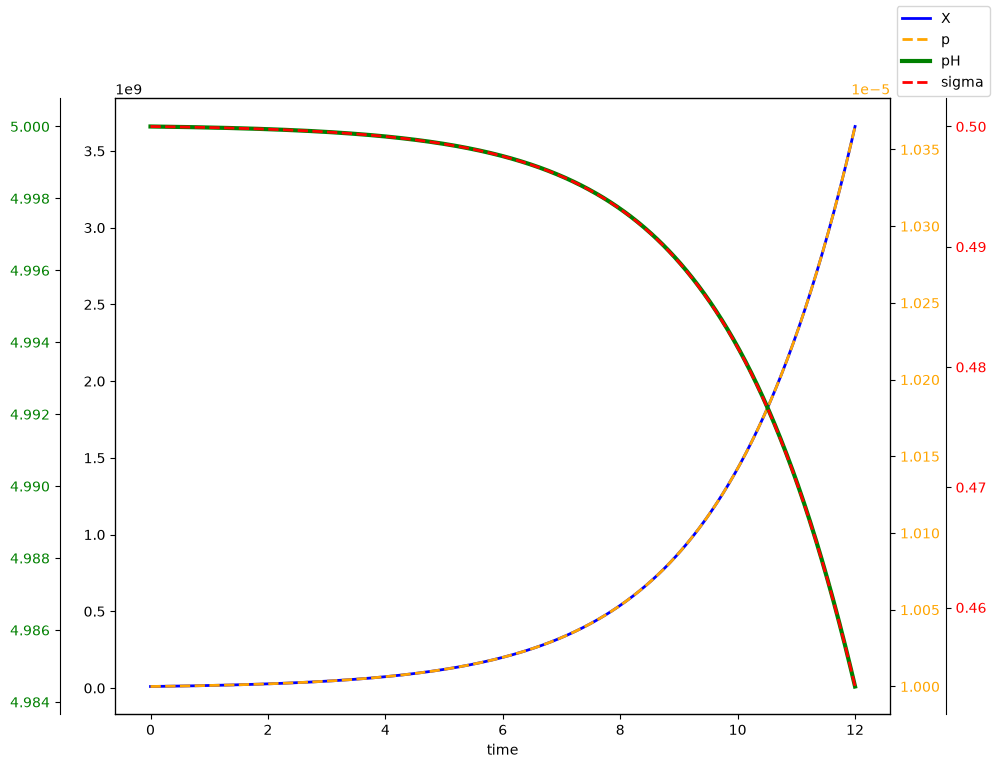

In [5]:
payload = {"y0": [X0, p0], "t_start": 0.0, "t_end": 12, "t_steps": 12 * 60}
kinetic_parameters = {"c1": c1, "c2": c2, "mu": mu, "q": q}
results = predict(model_input=payload, params=kinetic_parameters)
plot(results)

## Conclusion

Results makes sense, the plotting show the expected growth on bacterial 
concentration and growth in lactic acid concentration, parallel to the decrease 
on Ph values and sigma values which aligns with the acidity increase.

With this we can start thinking on how to build a user interface that allows the 
user to interact with the model and explore different scenarios, and also a 
system to store models.